# MLPs Classification of the MNIST Dataset

This notebook demonstrates how to use a Multi-Layer Perceptron (MLPs) neural network to classify handwritten digits from the MNIST dataset. MLPs use fully-connected hidden layers in their stucture.

The MNIST dataset contains 70,000 grayscale images of handwritten digits (0-9), each with a size of 28x28 pixels.

Dataset split:
- Training set: 60,000 images
- Test set: 10,000 images

Target variable: Digit class (0-9)

## Import Modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load the MNIST Dataset

In [2]:
# Load the dataset from keras datasets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# Display the shape of training and test data
print(X_train.shape)
print(X_test.shape)
# Each image has 28x28 pixels

(60000, 28, 28)
(10000, 28, 28)


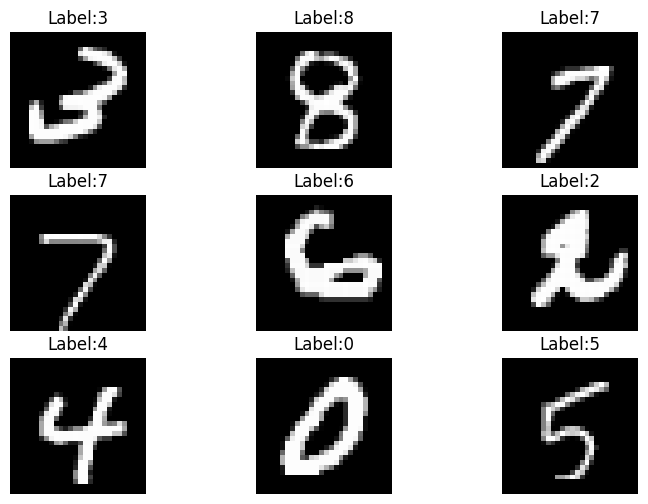

In [4]:
# Display 9 images from the training set adn their labels
plt.figure(figsize=(9, 6))
for n in range(9):
    i = np.random.randint(0, len(X_train), 1)
    ax = plt.subplot(3, 3, n+1)
    plt.imshow(X_train[i[0]], cmap='gray')
    plt.title('Label:' + str(y_train[i[0]]))
    plt.axis('off')

## Data Preprocessing

In [5]:
# Normalize pixel values to range [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [6]:
# Flatten the images from 28x28 to 784-dimensional vectors
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

In [7]:
# Print the shapes of data and label sets
print('Training data features', X_train.shape)
print('Training labels', y_train.shape)
print('Testing data features', X_test.shape)
print('Testing labels', y_test.shape)

Training data features (60000, 784)
Training labels (60000,)
Testing data features (10000, 784)
Testing labels (10000,)


# Build the MLP Model

In [8]:
# Define the layers in the MLP neural network
# Input layer - 784 features
inputs = Input(shape=(784,))
dense1 = Dense(units=512, activation='relu')(inputs)
dense2 = Dense(units=256, activation='relu')(dense1)
# Output layer - 10 classes
outputs = Dense(units=10, activation='softmax')(dense2)

In [9]:
# Define the model by providing the inputs and outputs
model = Model(inputs, outputs)

## Train the MLP Model

In [10]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
# Fit the model to the training dataset
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2, verbose=1)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.8937 - loss: 0.3521 - val_accuracy: 0.9658 - val_loss: 0.1145
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.9738 - loss: 0.0858 - val_accuracy: 0.9696 - val_loss: 0.1024
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9814 - loss: 0.0566 - val_accuracy: 0.9746 - val_loss: 0.0933
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9863 - loss: 0.0417 - val_accuracy: 0.9737 - val_loss: 0.1004
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9904 - loss: 0.0283 - val_accuracy: 0.9727 - val_loss: 0.1084


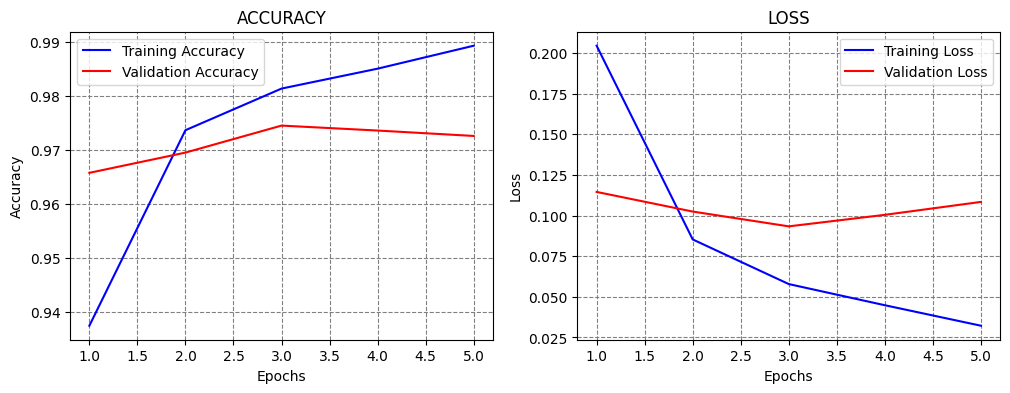

In [12]:
# Plot the accuracy and loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochsn = np.arange(1, len(train_loss)+1,1)
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
plt.plot(epochsn, acc, 'b', label='Training Accuracy')
plt.plot(epochsn, val_acc, 'r', label='Validation Accuracy')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('ACCURACY')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochsn,train_loss, 'b', label='Training Loss')
plt.plot(epochsn,val_loss, 'r', label='Validation Loss')
plt.grid(color='gray', linestyle='--')
plt.legend()
plt.title('LOSS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Evaluate the Model

In [13]:
# Calculate and print the accuracy on the test dataset
evals_test = model.evaluate(X_test, y_test)
print(f"Accuracy on test dataset: {evals_test[1]*100:5.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9732 - loss: 0.1119
Accuracy on test dataset: 97.57%


In [14]:
# Predict on test dataset
y_pred_probabilities = model.predict(X_test)
model_predictions = np.argmax(y_pred_probabilities, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [15]:
# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, model_predictions))

Confusion Matrix:
[[ 972    1    1    0    1    0    1    1    1    2]
 [   0 1130    2    1    0    0    0    0    2    0]
 [   2    1 1014    2    2    0    1    8    2    0]
 [   0    0    7  992    0    2    0    4    5    0]
 [   1    4    3    2  959    0    3    3    0    7]
 [   3    0    0   36    0  841    3    2    5    2]
 [   4    3    3    0    5    3  934    1    5    0]
 [   0   10    8    5    0    0    0 1003    0    2]
 [   3    2    5   12    4    2    0   10  930    6]
 [   3    2    0    7    7    2    0    6    0  982]]


The confusion matrix shows the classification results for each digit (0-9):
- Diagonal elements: Correctly classified digits
- Off-diagonal elements: Misclassifications (showing which digits were confused with each other)